In [1]:
from scipy.io import loadmat
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Local reference params, both floats
RATES = PARAMS.NPRW_rate_est
BIN_MS = 20 #RATES.get("bin_ms")
SIGMA_MS = RATES.get("sigma_ms")
THRESH = RATES.get("detect_threshold")
MS_BEFORE = float(RATES.get("remove_ms_before"))
TAIL_MS = float(RATES.get("remove_tail_ms_after"))
WIN_MS = (-600.0, 600.0)

NPRW_CKPT_OUT = OUT_BASE.parent / 'results' / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

In [2]:
INDEX = 1

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

Found Intan sessions: 63


In [3]:
# Jax imports
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
from jax import vmap, value_and_grad, jit
from jax.nn import softplus
from tensorflow_probability.substrates.jax.distributions import Poisson

from dynamax.generalized_gaussian_ssm import (
    ParamsGGSSM, GeneralizedGaussianSSM, EKFIntegrals,
    conditional_moments_gaussian_smoother as cmgs,
)
from dynamax.utils.utils import random_rotation

In [4]:
import json
# Sessions to treat as control (index into nprw_pp_folders); rest are stim
CONTROL_INDICES = [0]
SKIP_INDICES    = [62]

# Paths
PERI_ROOT      = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT = PERI_ROOT / "stim_reaches"
CTRL_PERI_ROOT = PERI_ROOT / "control_reaches"

nprw_pp_folders  = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_peaks_files = sorted(NPRW_CKPT_OUT.glob(f"rates__*bin{BIN_MS}ms*.npz"))
assert len(nprw_pp_folders) == len(nprw_peaks_files), "Mismatch between pp_ and rates__ files"

# Resolve stim_dur once from the first non-control session
stim_dur_global = None
for idx, nprw_peaks_folder in enumerate(nprw_peaks_files):
    if idx not in CONTROL_INDICES:
        _npz = np.load(list(STIM_PERI_ROOT.glob(
            f"peristim__NRR_RW{nprw_pp_folders[idx].name.split('NRR_RW',1)[1]}__BR_*.npz"
        ))[0], allow_pickle=True)
        stim_dur_global = float(json.loads(_npz['meta_json'].item())['recording_stim_dur'])
        print(f"stim_dur_global resolved from idx={idx}: {stim_dur_global} ms")
        break
    
stim_dur = stim_dur_global

stim_dur_global resolved from idx=1: 17.933333333333334 ms


In [5]:
all_observations_list = []
stim_ind_list         = []
trial_labels_list     = []   # 0=control, 1=stim
session_labels_list   = []   # index into nprw_pp_folders
centers_ms_by_session = {}
edges_ms_by_session   = {}

for idx, (nprw_pp_folder, nprw_peaks_folder) in enumerate(zip(nprw_pp_folders, nprw_peaks_files)):
    if idx in SKIP_INDICES:
        print(f"[{idx}] SKIPPED")
        continue
    is_control = idx in CONTROL_INDICES
    # Load peaks
    nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
    nprw_peak_samps, _ = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
    nprw_peak_ms = {k: (v / 30000) * 1000.0 for k, v in nprw_peak_samps.items()}
    SESSION = nprw_peaks_si_obj['meta'].item()['session']

    session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]

    if is_control:
        peri_dir = CTRL_PERI_ROOT
        glob_pat = f"peristim__NRR_RW*.npz"
    else:
        peri_dir = STIM_PERI_ROOT
        glob_pat = f"peristim__NRR_RW{session_name}__BR_*.npz"

    matches = list(peri_dir.glob(glob_pat))
    if not matches:
        print(f"  WARNING: no peristim file found for idx={idx}, skipping")
        continue
    npz_path = matches[0]
    npz      = np.load(npz_path, allow_pickle=True)

    if is_control:
        event_ms = npz['event_ms']
        peak_ms_dedup = npz['NPRW_peak_ms_dedup']
        if isinstance(peak_ms_dedup, np.ndarray) and peak_ms_dedup.dtype == object:
            peak_ms_dedup = peak_ms_dedup.item()

        counts_ch, centers_ms, edges_ms, _ = rcp.bin_counts_around_stim(
            peak_ms_dedup, BIN_MS, event_ms,
            MS_BEFORE, (stim_dur + TAIL_MS), WIN_MS
        )
    else:
        counts_ch  = npz['NPRW_counts']        # (n_trials, n_ch, n_bins)
        centers_ms = npz["NPRW_rel_t"]
        edges_ms   = npz["NPRW_edges_ms"]
    prestim_mask = centers_ms < 0
    counts_ch  = counts_ch[:, :, prestim_mask]
    centers_ms = centers_ms[prestim_mask]
    edges_ms   = edges_ms[:prestim_mask.sum() + 1]
    
    centers_ms_by_session[idx] = centers_ms
    edges_ms_by_session[idx]   = edges_ms

    meta       = json.loads(npz['meta_json'].item())
    # stim_dur   = meta.get("recording_stim_dur", 0)
    nprw_meta  = json.loads(npz["nprw_meta_json"].item())
    stim_ch_0  = np.asarray(nprw_meta["stim_channels"], dtype=int) - 1

    n_trials_i, n_ch, n_bins = counts_ch.shape
    ir_idx = int(jnp.argmin(jnp.abs(jnp.array(centers_ms))))

    obs = jnp.array(counts_ch.transpose(0, 2, 1))  # (n_trials, n_bins, n_ch)
    
    stim_ind = jnp.zeros((n_trials_i, n_bins, n_ch))  # all zeros, pulse is outside prestim
    all_observations_list.append(obs)
    stim_ind_list.append(stim_ind)
    trial_labels_list.append(jnp.full(n_trials_i, 0 if is_control else 1, dtype=jnp.int32))
    session_labels_list.append(jnp.full(n_trials_i, idx, dtype=jnp.int32))

# Concatenate across all sessions
all_observations_combined_before = jnp.concatenate(all_observations_list, axis=0)
stim_ind_combined         = jnp.concatenate(stim_ind_list,         axis=0)
trial_labels              = jnp.concatenate(trial_labels_list,      axis=0)
session_labels            = jnp.concatenate(session_labels_list,    axis=0)

print(f"all_observations_combined: {all_observations_combined_before.shape}")
print(f"stim_ind_combined:         {stim_ind_combined.shape}")
print(f"trial_labels:              {trial_labels.shape}  (0=ctrl, 1=stim)")
print(f"session_labels:            {session_labels.shape}  unique={jnp.unique(session_labels)}")

[62] SKIPPED
all_observations_combined: (788, 29, 128)
stim_ind_combined:         (788, 29, 128)
trial_labels:              (788,)  (0=ctrl, 1=stim)
session_labels:            (788,)  unique=[ 0  1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61]


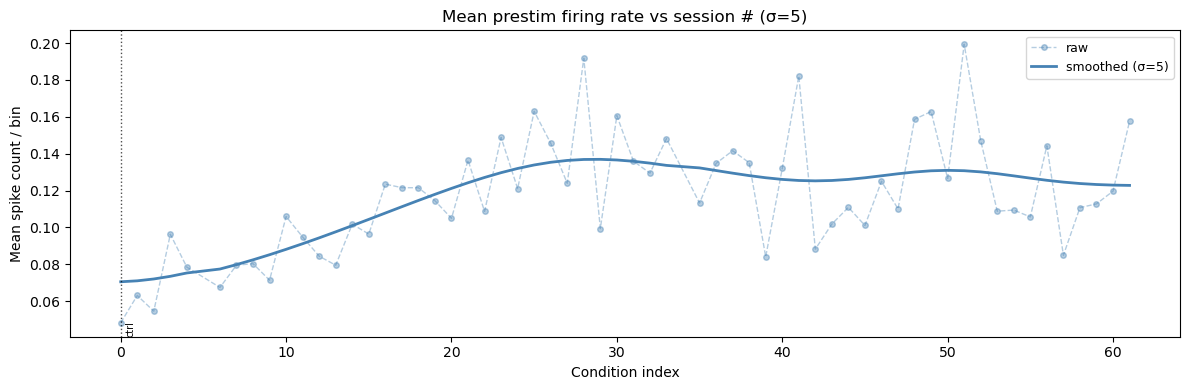

In [6]:
%matplotlib inline
from scipy.ndimage import gaussian_filter1d

DRIFT_SIGMA_SESSIONS = 5

# Prestim mask from the first session's centers_ms
_centers = list(centers_ms_by_session.values())[0]
prestim_mask = _centers < 0  # (n_bins,)

trial_mean_fr = np.array(all_observations_combined_before).mean(axis=1)  # (n_trials, n_ch)

session_labels_np = np.array(session_labels)
unique_sessions = np.unique(session_labels_np)

# One scalar per session: mean across trials AND channels
session_mean_fr = np.array([
    trial_mean_fr[session_labels_np == s].mean()
    for s in unique_sessions
])

smoothed = gaussian_filter1d(session_mean_fr, sigma=DRIFT_SIGMA_SESSIONS)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(unique_sessions, session_mean_fr, color="steelblue", alpha=0.4, lw=1.0, ls="--", marker="o", ms=4, label="raw")
ax.plot(unique_sessions, smoothed,        color="steelblue", alpha=1.0, lw=2.0, label=f"smoothed (σ={DRIFT_SIGMA_SESSIONS})")

for s in unique_sessions:
    if int(s) in CONTROL_INDICES:
        ax.axvline(s, color="black", lw=1.0, ls=":", alpha=0.7)
        ax.text(s + 0.3, ax.get_ylim()[0], "ctrl", fontsize=7, va="bottom", rotation=90)

ax.set_xlabel("Condition index")
ax.set_ylabel("Mean spike count / bin")
ax.set_title(f"Mean prestim firing rate vs session # (σ={DRIFT_SIGMA_SESSIONS})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
state_dim = 4

def make_params(C, d, A, B, mu0):
    return ParamsGGSSM(
        initial_mean=mu0,
        initial_covariance=jnp.eye(state_dim),
        dynamics_function=lambda z, u: A @ z + B @ u,
        dynamics_covariance=0.001 * jnp.eye(state_dim),
        emission_mean_function=lambda z, u: softplus(C @ z + d),
        emission_cov_function=lambda z, u: jnp.diag(softplus(C @ z + d)),
        emission_dist=lambda mu, Sigma: Poisson(rate=mu),
    )

def loss_fn(theta, observations, inputs):
    C, log_d, A, B, mu0 = theta
    sigma_max = jnp.linalg.norm(A, ord=2)
    penalty_A = 1e2 * jnp.maximum(0.0, sigma_max - 1.0) ** 2
    params = make_params(C, jnp.exp(log_d), A, B, mu0)
    posts = vmap(lambda obs, inp: cmgs(params, EKFIntegrals(), obs, inputs=inp))(observations, inputs)
    return -jnp.sum(posts.marginal_loglik) + penalty_A

In [8]:
session_mean_fr_by_ch = np.array([
    trial_mean_fr[session_labels_np == s].mean(axis=0)
    for s in unique_sessions
])
session_smoothed_by_ch = gaussian_filter1d(session_mean_fr_by_ch, sigma=DRIFT_SIGMA_SESSIONS, axis=0)

session_idx_to_pos = {int(s): i for i, s in enumerate(unique_sessions)}

session_smoothed_by_ch_safe = np.clip(session_smoothed_by_ch, 1e-6, None)

# Reference: smoothed prestim mean per channel for the first control session
ctrl_session_idx = CONTROL_INDICES[0]
ctrl_pos = session_idx_to_pos[ctrl_session_idx]
ctrl_mean_by_ch = session_smoothed_by_ch_safe[ctrl_pos]  # (n_ch,)

scale_factors = np.array([
    ctrl_mean_by_ch / session_smoothed_by_ch_safe[session_idx_to_pos[int(s)]]
    for s in session_labels_np
])  # (n_trials, n_ch)

scale_factors = scale_factors[:, None, :]  # (n_trials, 1, n_ch)

all_observations_corrected = jnp.array(
    np.array(all_observations_combined_before) * scale_factors
)

print(f"min before: {float(all_observations_combined_before.min()):.3f}  min after: {float(all_observations_corrected.min()):.3f}")
print(f"max before: {float(all_observations_combined_before.max()):.3f}  max after: {float(all_observations_corrected.max()):.3f}")
print(f"scale factor range: [{scale_factors.min():.3f}, {scale_factors.max():.3f}]")

all_observations_combined = all_observations_corrected

min before: 0.000  min after: 0.000
max before: 5.000  max after: 10.934
scale factor range: [0.074, 4.793]


In [9]:
n_epochs = 400
BATCH_SIZE = 32

key = jr.key(1)
key1, key2 = jr.split(key, 2)
state_dim = 4
num_trials, num_timesteps, n_ch = all_observations_combined.shape

C_init    = 0.5 * jr.normal(key2, shape=(n_ch, state_dim))
d_init    = jnp.mean(all_observations_combined[trial_labels == 0], axis=(0, 1))
log_d_init = jnp.log(jnp.clip(d_init, 1e-6, None))
A_init    = jnp.eye(state_dim)
B_init    = jnp.zeros((state_dim, n_ch)) + 0.01 * jr.normal(key2, shape=(state_dim, n_ch))
mu0_init  = jnp.zeros(state_dim)
theta_pre = (C_init, log_d_init, A_init, B_init, mu0_init)

optimizer_pre = optax.adam(1e-2)
opt_state_pre = optimizer_pre.init(theta_pre)

@jit
def step_batch_pre(theta, opt_state, obs_batch, inp_batch):
    loss, grads = value_and_grad(loss_fn)(theta, obs_batch, inp_batch)
    updates, new_opt_state = optimizer_pre.update(grads, opt_state)
    return optax.apply_updates(theta, updates), new_opt_state, loss

indices = jnp.arange(num_trials)
losses_pre = []

for epoch in range(n_epochs):
    perm = jr.permutation(jr.key(epoch), indices)
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, num_trials, BATCH_SIZE):
        batch_idx = perm[start:start + BATCH_SIZE]
        theta_pre, opt_state_pre, loss = step_batch_pre(
            theta_pre, opt_state_pre,
            all_observations_combined[batch_idx],
            stim_ind_combined[batch_idx],
        )
        epoch_loss += float(loss); n_batches += 1
    losses_pre.append(epoch_loss / n_batches)
    if epoch % 50 == 0:
        print(f"epoch {epoch:4d}  loss={losses_pre[-1]:.2f}")

C_fit, log_d_fit, A_fit, B_fit, mu0_fit = theta_pre
print('singular values of A_fit:', jnp.linalg.svd(A_fit, compute_uv=False))

epoch    0  loss=71553.04
epoch   50  loss=27780.29
epoch  100  loss=27745.10
epoch  150  loss=27727.53
epoch  200  loss=27717.75
epoch  250  loss=27697.26
epoch  300  loss=27694.69
epoch  350  loss=27692.95
singular values of A_fit: [1.0062207  0.96188635 0.85613126 0.15506433]


In [10]:
params_fit = make_params(C_fit, jnp.exp(log_d_fit), A_fit, B_fit, mu0_fit)
posts_fit  = vmap(lambda obs, inp: cmgs(params_fit, EKFIntegrals(), obs, inputs=inp))(
    all_observations_combined, stim_ind_combined
)
predicted  = softplus(posts_fit.filtered_means @ C_fit.T + jnp.exp(log_d_fit))
innovations = all_observations_combined - predicted

U, S, Vt = jnp.linalg.svd(C_fit, full_matrices=False)
R = Vt.T
z_combined = posts_fit.filtered_means @ R

In [11]:
unique_sessions = jnp.unique(session_labels)
z_by_session, posts_by_session, innovations_by_session = {}, {}, {}

for sess_idx in unique_sessions:
    mask = session_labels == int(sess_idx)
    s = int(sess_idx)
    z_by_session[s]            = z_combined[mask]
    posts_by_session[s]        = jax.tree.map(lambda x: x[mask], posts_fit)
    innovations_by_session[s]  = innovations[mask]

control_mask = trial_labels == 0
stim_mask    = trial_labels == 1
z_control = z_combined[control_mask]
z_stim    = z_combined[stim_mask]

## Plots

In [12]:
import plotly.graph_objects as go

def plot_latent_phase_portrait_sessions(
    z_by_session,
    centers_ms_by_session,
    control_indices,
    alpha_trials=0.15,
    plot_sessions=None,
    epoch="full",
    pre_trim_bins=0,
    post_trim_bins=0,
    show_trials=True,
    show_markers=True,
    show_pre_post=False,  # if True, pre=desaturated, post=full color
    x_range=None,
    y_range=None,
    z_range=None,
):
    if plot_sessions is None:
        plot_sessions = sorted(z_by_session.keys())

    gap_bin_by_session = {}
    for k in plot_sessions:
        cms = centers_ms_by_session[k]
        gap_bin_by_session[k] = int(np.argmax(np.diff(cms))) + 1  # first post-gap bin index

    def slice_epoch(z, cms, gap_bin):
        if epoch == "pre":
            end = gap_bin - pre_trim_bins
            return z[:, :end, :], cms[:end]
        elif epoch == "post":
            start = gap_bin + post_trim_bins
            return z[:, start:, :], cms[start:]
        return z, cms

    colorscale = plt.cm.jet(np.linspace(0.05, 0.9, len(plot_sessions)))
    fig = go.Figure()

    for i, sess_idx in enumerate(plot_sessions):
        z         = z_by_session[sess_idx]
        cms       = centers_ms_by_session[sess_idx]
        gap_bin   = gap_bin_by_session[sess_idx]
        is_ctrl   = sess_idx in control_indices
        color_rgb = "rgb(0,0,0)" if is_ctrl else f"rgb({int(colorscale[i,0]*255)},{int(colorscale[i,1]*255)},{int(colorscale[i,2]*255)})"
        label     = f"{'ctrl' if is_ctrl else 'stim'} [{sess_idx}]"

        z_ep, cms_ep = slice_epoch(z, cms, gap_bin)
        ir_idx = int(np.argmin(np.abs(cms_ep)))

        mean_z = z_ep.mean(axis=0)
        x, y, zz = mean_z[:, 0], mean_z[:, 1], mean_z[:, 2]
        if show_trials:
            for trial in range(z_ep.shape[0]):
                fig.add_trace(go.Scatter3d(
                    x=z_ep[trial, :, 0], y=z_ep[trial, :, 1], z=z_ep[trial, :, 2],
                    mode="lines",
                    line=dict(color=color_rgb, width=1),
                    opacity=alpha_trials,
                    showlegend=False,
                ))
        if show_pre_post and epoch == "full":
            x_pre,  y_pre,  zz_pre  = x[:gap_bin], y[:gap_bin], zz[:gap_bin]
            x_post, y_post, zz_post = x[gap_bin:],  y[gap_bin:],  zz[gap_bin:]
            mode = "lines" if not show_markers else "markers+lines"

            fig.add_trace(go.Scatter3d(
                x=x_pre, y=y_pre, z=zz_pre,
                mode=mode,
                marker=dict(size=3, color=color_rgb),
                line=dict(color=color_rgb, width=2, dash="dash"),
                name=label + " pre",
                showlegend=False,
            ))
            fig.add_trace(go.Scatter3d(
                x=x_post, y=y_post, z=zz_post,
                mode=mode,
                marker=dict(size=3, color=cms_ep, colorscale="Viridis", showscale=(i == 0),
                    colorbar=dict(title="Time (ms)", thickness=15, x=1.0)),
                line=dict(color=color_rgb, width=3),
                name=label,
            ))
        else:
            x_plot, y_plot, z_plot = x, y, zz
            if epoch == "full":
                x_plot = np.insert(np.array(x), gap_bin, np.nan)
                y_plot = np.insert(np.array(y), gap_bin, np.nan)
                z_plot = np.insert(np.array(zz), gap_bin, np.nan)

            fig.add_trace(go.Scatter3d(
                x=x_plot, y=y_plot, z=z_plot,
                mode="lines" if not show_markers else "markers+lines",
                marker=dict(size=3, color=cms_ep, colorscale="Viridis", showscale=(i == 0),
                    colorbar=dict(title="Time (ms)", thickness=15, x=1.0)),
                line=dict(color=color_rgb, width=3),
                name=label,
            ))

        if show_markers:
            if epoch in ("post", "full"):
                fig.add_trace(go.Scatter3d(
                    x=[x[ir_idx]], y=[y[ir_idx]], z=[zz[ir_idx]],
                    mode="markers",
                    marker=dict(size=6, color=color_rgb, symbol="diamond"),
                    line=dict(width=0),
                    showlegend=False,
                ))
            fig.add_trace(go.Scatter3d(
                x=[x[0]], y=[y[0]], z=[zz[0]],
                mode="markers",
                marker=dict(size=6, color=color_rgb, symbol="circle"),
                line=dict(width=0),
                showlegend=False,
            ))
            
    fig.update_layout(
        title=f"Latent trajectories — {epoch} stim",
        scene=dict(
            xaxis=dict(title="z₁", **({"range": x_range} if x_range else {})),
            yaxis=dict(title="z₂", **({"range": y_range} if y_range else {})),
            zaxis=dict(title="z₃", **({"range": z_range} if z_range else {})),
            aspectmode="cube",
        ),
        legend=dict(itemsizing="constant", x=1.15, y=0.4),
        margin=dict(l=0, r=0, b=0, t=40),
        width=1000, height=800,
    )
    return fig

In [13]:
fig = plot_latent_phase_portrait_sessions(
    z_by_session=z_by_session,
    centers_ms_by_session=centers_ms_by_session,
    control_indices=CONTROL_INDICES,
    alpha_trials=0.05,
    plot_sessions=None,
    epoch="full",
    show_pre_post=False,
    show_trials=False,
    show_markers=False,
)
fig.show()

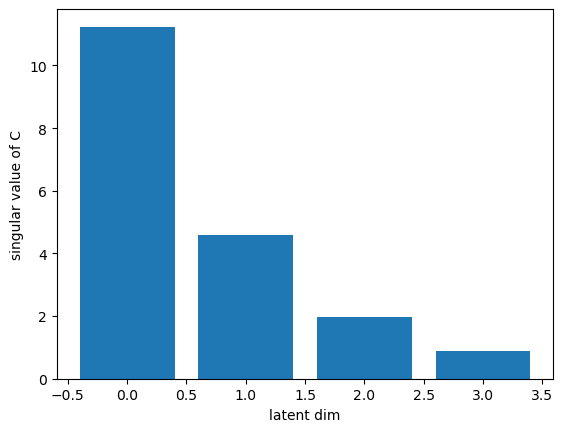

In [14]:
U, S, Vt = jnp.linalg.svd(C_fit, full_matrices=False)
plt.bar(range(len(S)), S)
plt.xlabel("latent dim"); plt.ylabel("singular value of C")
plt.show()